# DBSCAN Clustering on Moon-Shaped Data

This notebook demonstrates the `DBSCAN` clustering algorithm implemented in the `jiayi_ml` package.

DBSCAN stands for Density-Based Spatial Clustering of Applications with Noise. It is useful when clusters are not spherical and when the data may contain noise points.

This example emphasizes:

1. Density-based clustering.
2. Non-spherical cluster structure.
3. Noise point detection.
4. The role of `eps` and `min_samples`.
5. Comparison with K-Means.
6. Interpretation of clustering results without using labels for fitting.


## 1. Problem Statement

DBSCAN is an unsupervised clustering algorithm.

Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance. Instead, it defines clusters as dense regions of points separated by lower-density regions.

DBSCAN is especially useful when:

- clusters are non-spherical,
- clusters are separated by density rather than by centroids,
- noise points should be identified explicitly.

The main question in this notebook is:

> Can DBSCAN recover non-spherical cluster structure and identify noise points?

A synthetic moon-shaped dataset is used because it highlights a major limitation of K-Means and a major strength of DBSCAN.


In [1]:
from pathlib import Path
import sys

# Make the local package importable whether the notebook is run from the
# project root or from inside the examples directory.
current_path = Path.cwd().resolve()
for candidate in [current_path, *current_path.parents]:
    if (candidate / "src" / "jiayi_ml").exists():
        sys.path.insert(0, str(candidate / "src"))
        PROJECT_ROOT = candidate
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons

from jiayi_ml.preprocessing import StandardScaler
from jiayi_ml.unsupervised import DBSCAN, KMeans

np.random.seed(438)
pd.set_option("display.precision", 4)


## 2. Generate Moon-Shaped Data

The dataset is generated with `sklearn.datasets.make_moons`.

Although synthetic labels are available from the generator, DBSCAN does not use them during fitting. The labels are used only after clustering to interpret whether the discovered clusters align with the known synthetic structure.

The moon-shaped data is intentionally non-spherical, making it difficult for centroid-based methods such as K-Means.


In [2]:
X, true_labels = make_moons(
    n_samples=450,
    noise=0.08,
    random_state=438,
)

df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
df["true_group"] = true_labels

print("Feature matrix shape:", X.shape)
print("Number of true synthetic groups:", len(np.unique(true_labels)))

df.head()


Feature matrix shape: (450, 2)
Number of true synthetic groups: 2


,feature_1,feature_2,true_group
0,-0.4055,0.7316,0
1,0.4213,0.8424,0
2,1.2436,-0.2819,1
3,0.4107,-0.2996,1
4,0.2787,-0.1927,1


## 3. Exploratory Visualization

The first plot shows the unlabeled data, which is the actual information available to DBSCAN. The second plot uses the synthetic labels only for interpretation.

The curved cluster shape is the key reason this dataset is useful for DBSCAN.


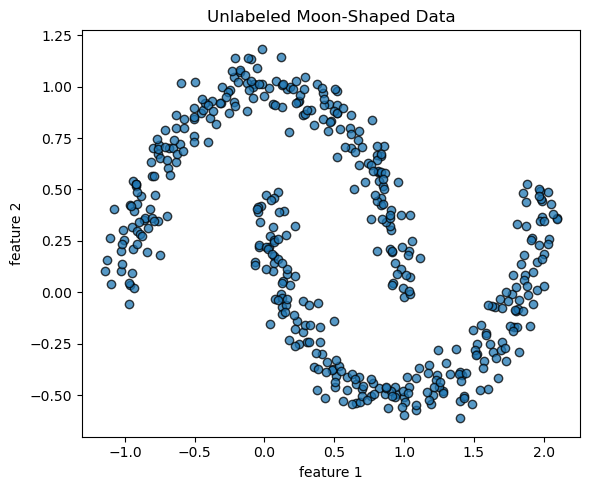

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.75, edgecolors="k")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Unlabeled Moon-Shaped Data")
plt.tight_layout()
plt.show()


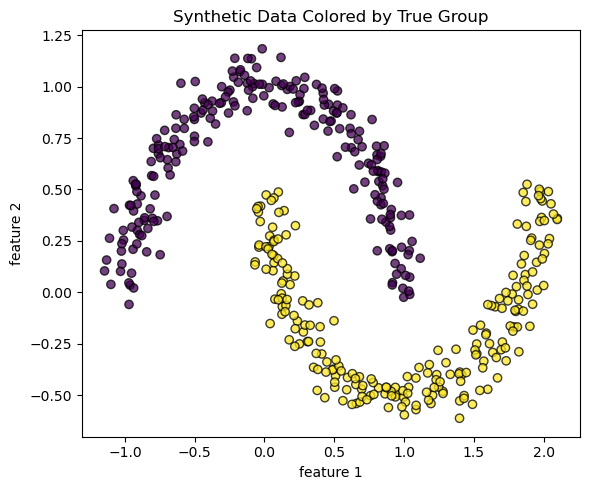

In [4]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=true_labels, alpha=0.75, edgecolors="k")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Synthetic Data Colored by True Group")
plt.tight_layout()
plt.show()


The two groups form curved arcs. A centroid-based algorithm may split this structure incorrectly because the clusters are not compact around a center.


## 4. Standardization

DBSCAN uses distances to define local neighborhoods. Therefore, feature scaling is important.

The scaler is fit on the full dataset here because this is an unsupervised exploratory example without a train/test split. In supervised learning, preprocessing should be fit only on the training data.


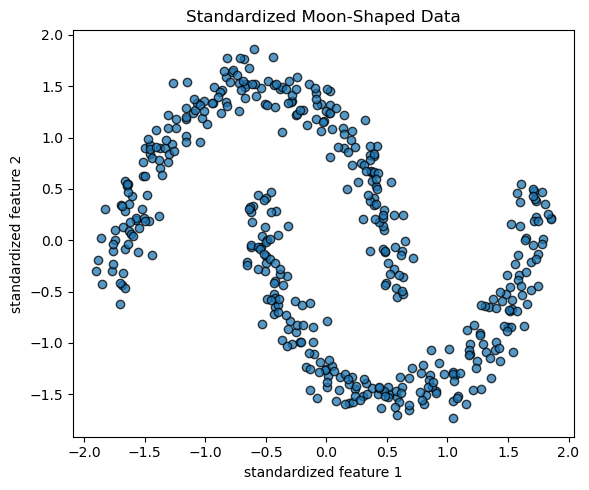

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.75, edgecolors="k")
plt.xlabel("standardized feature 1")
plt.ylabel("standardized feature 2")
plt.title("Standardized Moon-Shaped Data")
plt.tight_layout()
plt.show()


## 5. Fit DBSCAN

DBSCAN has two key hyperparameters:

- `eps`: the radius used to define a local neighborhood.
- `min_samples`: the minimum number of points required for a point to be considered a core point.

Points that do not belong to any dense region are labeled as `-1`, meaning noise.


In [6]:
dbscan = DBSCAN(
    eps=0.25,
    min_samples=5,
    metric="euclidean",
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels, counts = np.unique(dbscan_labels, return_counts=True)
cluster_summary = pd.DataFrame(
    {
        "label": unique_labels,
        "count": counts,
    }
)

cluster_summary


,label,count
0,0,225
1,1,225


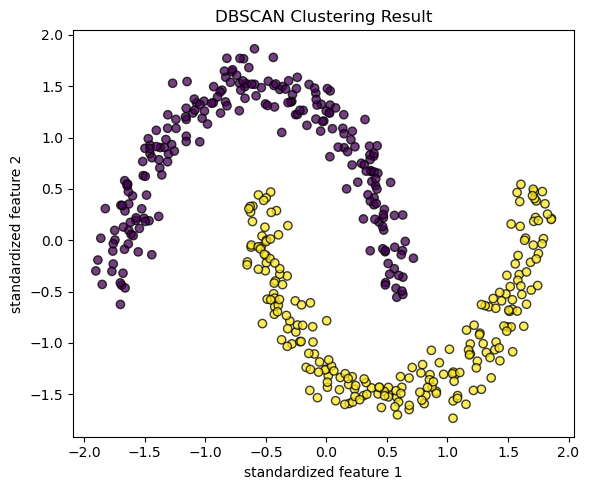

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, alpha=0.75, edgecolors="k")
plt.xlabel("standardized feature 1")
plt.ylabel("standardized feature 2")
plt.title("DBSCAN Clustering Result")
plt.tight_layout()
plt.show()


The DBSCAN labels show the discovered dense regions. If label `-1` appears, those points are treated as noise.

Unlike K-Means, DBSCAN does not force every point into a cluster.


## 6. Core Samples and Noise Points

DBSCAN distinguishes between:

- core points: points with enough neighbors,
- border points: points reachable from a core point,
- noise points: points not assigned to any cluster.

The custom implementation stores core sample indices and core sample coordinates.


In [8]:
print("Number of core samples:", len(dbscan.core_sample_indices_))
print("Number of noise points:", int(np.sum(dbscan_labels == -1)))
print("Core sample matrix shape:", dbscan.components_.shape)


Number of core samples: 448
Number of noise points: 0
Core sample matrix shape: (448, 2)


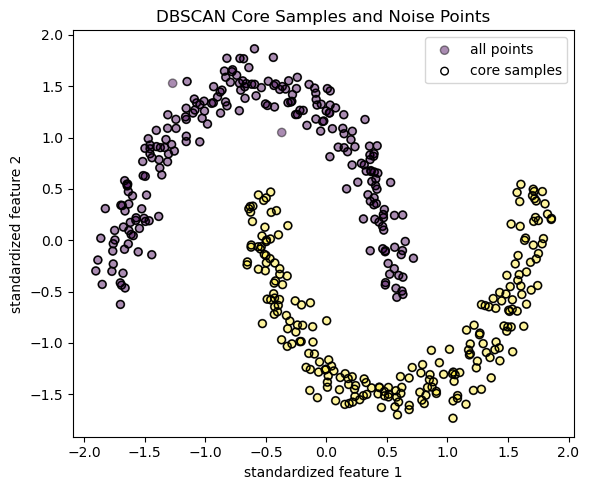

In [9]:
noise_mask = dbscan_labels == -1
core_indices = dbscan.core_sample_indices_

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, alpha=0.45, edgecolors="k", label="all points")
plt.scatter(
    X_scaled[core_indices, 0],
    X_scaled[core_indices, 1],
    s=30,
    facecolors="none",
    edgecolors="k",
    label="core samples",
)
if np.any(noise_mask):
    plt.scatter(
        X_scaled[noise_mask, 0],
        X_scaled[noise_mask, 1],
        marker="x",
        s=70,
        label="noise points",
    )
plt.xlabel("standardized feature 1")
plt.ylabel("standardized feature 2")
plt.title("DBSCAN Core Samples and Noise Points")
plt.legend()
plt.tight_layout()
plt.show()


Core points form the dense interior of clusters. Noise points, if present, indicate observations that do not belong to any sufficiently dense neighborhood.


## 7. Comparison with K-Means

K-Means assumes clusters are compact around centroids. The moon-shaped dataset violates this assumption.

The following comparison fits K-Means with two clusters. K-Means is given the correct number of synthetic groups, but it still struggles because the cluster shape does not match its assumptions.


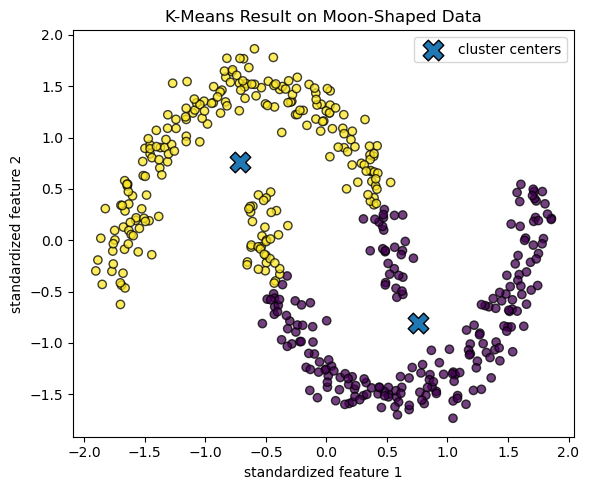

In [10]:
kmeans = KMeans(
    n_clusters=2,
    init="k-means++",
    n_init=10,
    random_state=438,
)

kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, alpha=0.75, edgecolors="k")
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=220,
    edgecolors="k",
    label="cluster centers",
)
plt.xlabel("standardized feature 1")
plt.ylabel("standardized feature 2")
plt.title("K-Means Result on Moon-Shaped Data")
plt.legend()
plt.tight_layout()
plt.show()


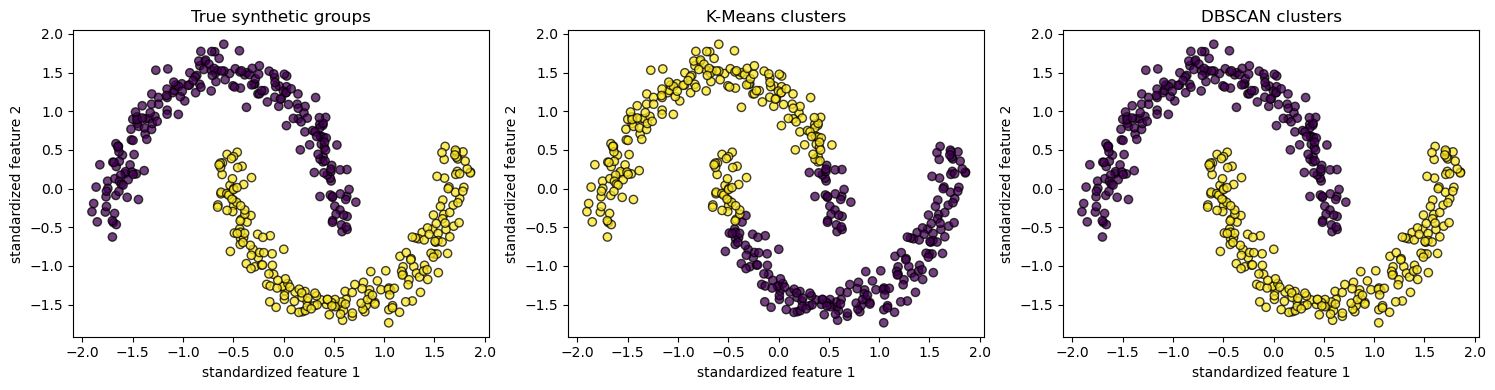

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=true_labels, alpha=0.75, edgecolors="k")
axes[0].set_title("True synthetic groups")

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, alpha=0.75, edgecolors="k")
axes[1].set_title("K-Means clusters")

axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, alpha=0.75, edgecolors="k")
axes[2].set_title("DBSCAN clusters")

for ax in axes:
    ax.set_xlabel("standardized feature 1")
    ax.set_ylabel("standardized feature 2")

plt.tight_layout()
plt.show()


This comparison shows why algorithm assumptions matter.

K-Means partitions the space based on distances to centroids, which can split curved clusters incorrectly. DBSCAN uses local density connectivity, so it can follow non-spherical shapes more naturally.


## 8. Sensitivity to eps

The `eps` parameter controls neighborhood size.

- If `eps` is too small, many points may be labeled as noise.
- If `eps` is too large, separate clusters may be merged.
- A useful value depends on the scale and density of the data.


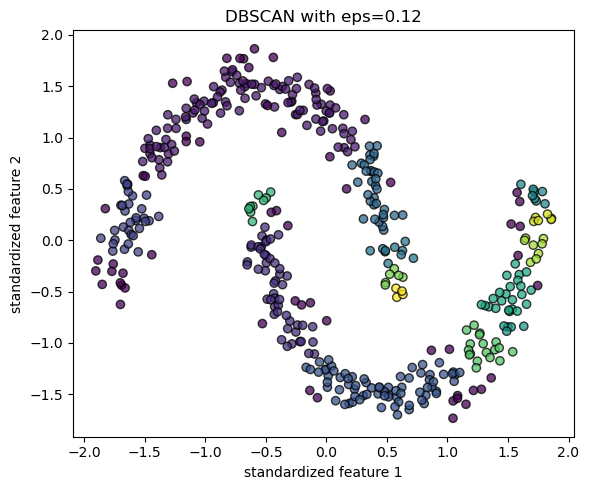

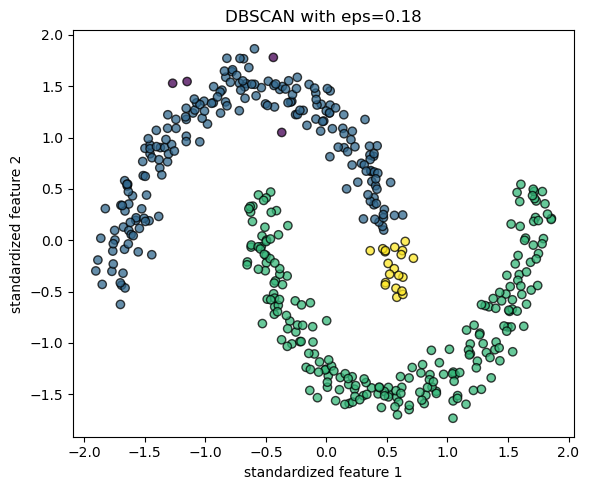

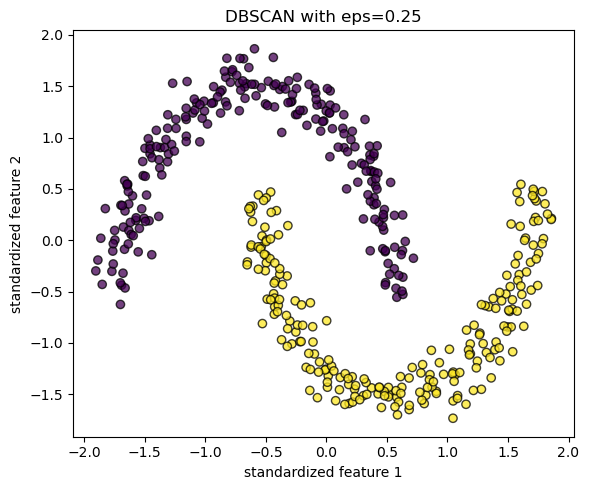

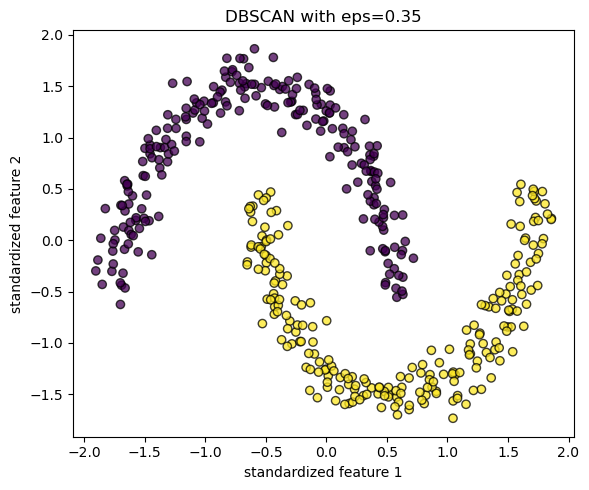

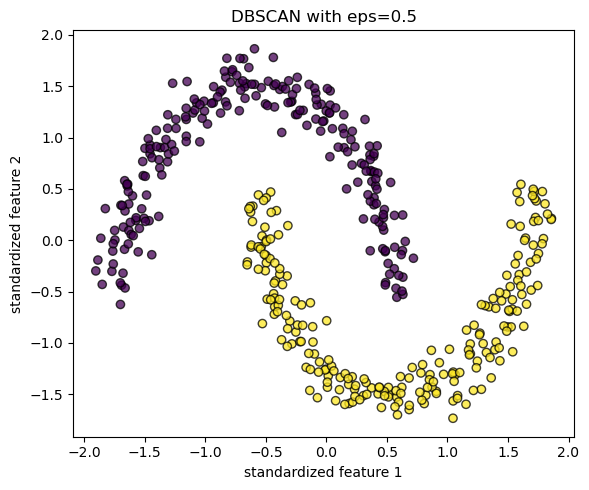

,eps,n_clusters_excluding_noise,n_noise_points
0,0.12,15,58
1,0.18,3,4
2,0.25,2,0
3,0.35,2,0
4,0.50,2,0


In [12]:
eps_values = [0.12, 0.18, 0.25, 0.35, 0.50]

eps_results = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_scaled)
    
    non_noise_labels = labels[labels != -1]
    n_clusters = len(np.unique(non_noise_labels)) if non_noise_labels.size > 0 else 0
    n_noise = int(np.sum(labels == -1))
    
    eps_results.append(
        {
            "eps": eps,
            "n_clusters_excluding_noise": n_clusters,
            "n_noise_points": n_noise,
        }
    )
    
    plt.figure(figsize=(6, 5))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, alpha=0.75, edgecolors="k")
    plt.xlabel("standardized feature 1")
    plt.ylabel("standardized feature 2")
    plt.title(f"DBSCAN with eps={eps}")
    plt.tight_layout()
    plt.show()

eps_results_df = pd.DataFrame(eps_results)
eps_results_df


The `eps` comparison illustrates that DBSCAN is sensitive to neighborhood radius. The same algorithm can produce very different clustering results depending on this parameter.

This sensitivity is not a flaw unique to DBSCAN; it reflects the fact that density is a scale-dependent concept.


## 9. Sensitivity to min_samples

The `min_samples` parameter controls how many nearby points are required for a point to become a core point.

Larger values make the density requirement stricter. This can reduce spurious clusters but may also label more points as noise.


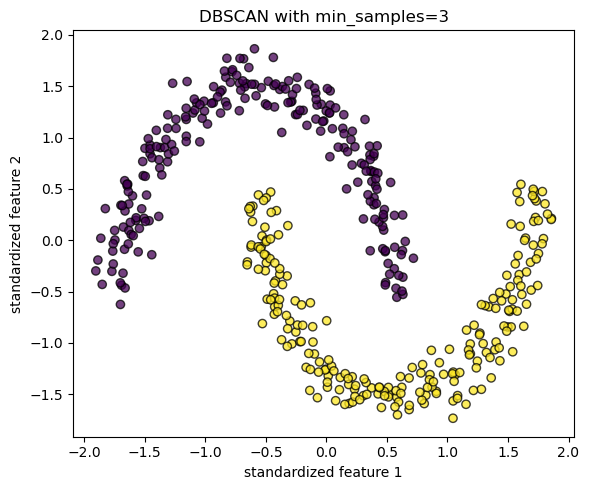

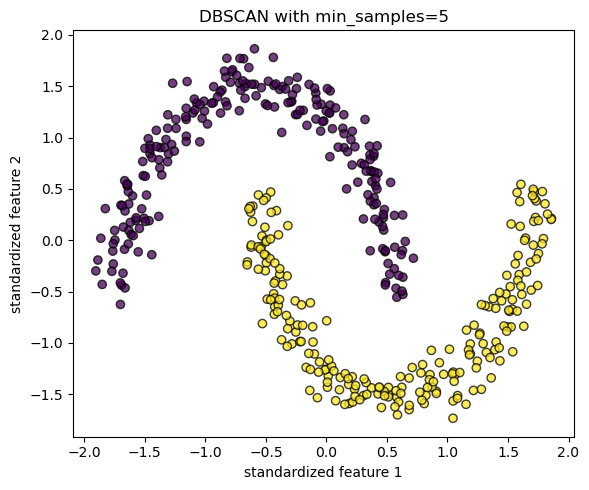

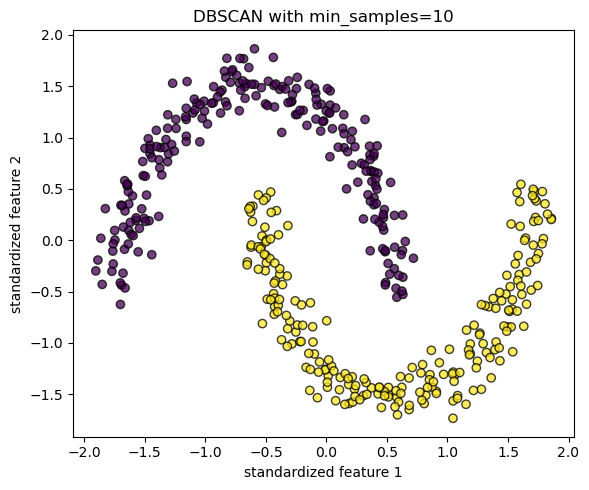

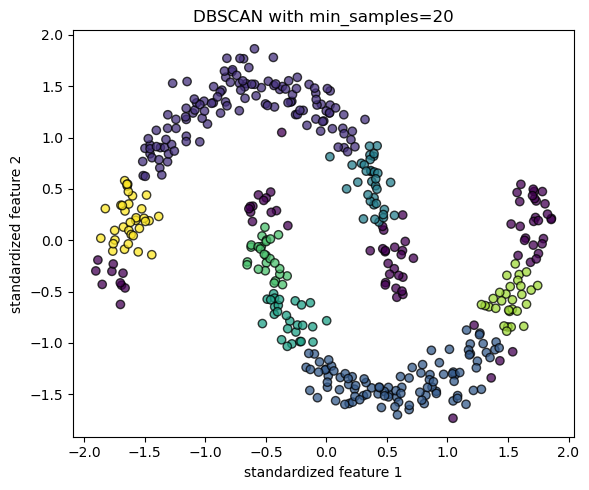

,min_samples,n_clusters_excluding_noise,n_noise_points
0,3,2,0
1,5,2,0
2,10,2,0
3,20,7,78


In [13]:
min_samples_values = [3, 5, 10, 20]

min_samples_results = []

for min_samples in min_samples_values:
    model = DBSCAN(eps=0.25, min_samples=min_samples)
    labels = model.fit_predict(X_scaled)
    
    non_noise_labels = labels[labels != -1]
    n_clusters = len(np.unique(non_noise_labels)) if non_noise_labels.size > 0 else 0
    n_noise = int(np.sum(labels == -1))
    
    min_samples_results.append(
        {
            "min_samples": min_samples,
            "n_clusters_excluding_noise": n_clusters,
            "n_noise_points": n_noise,
        }
    )
    
    plt.figure(figsize=(6, 5))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, alpha=0.75, edgecolors="k")
    plt.xlabel("standardized feature 1")
    plt.ylabel("standardized feature 2")
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.tight_layout()
    plt.show()

min_samples_results_df = pd.DataFrame(min_samples_results)
min_samples_results_df


The `min_samples` comparison shows how the definition of a dense region changes as the core-point requirement becomes stricter.


## 10. Compare Clusters with True Synthetic Groups

True labels are not used for DBSCAN fitting. However, since this is synthetic data, we can compare discovered labels with the known groups after clustering.

The numeric cluster IDs are arbitrary. A successful clustering should show that each true group mostly corresponds to one discovered cluster.


In [14]:
comparison_df = pd.DataFrame(
    {
        "true_group": true_labels,
        "dbscan_label": dbscan_labels,
        "kmeans_label": kmeans_labels,
    }
)

dbscan_contingency = pd.crosstab(
    comparison_df["true_group"],
    comparison_df["dbscan_label"],
    rownames=["true group"],
    colnames=["DBSCAN label"],
)

kmeans_contingency = pd.crosstab(
    comparison_df["true_group"],
    comparison_df["kmeans_label"],
    rownames=["true group"],
    colnames=["K-Means label"],
)

print("DBSCAN contingency table")
display(dbscan_contingency)

print("K-Means contingency table")
display(kmeans_contingency)


DBSCAN contingency table


DBSCAN label,0,1
true group,,
0,225,0
1,0,225


K-Means contingency table


K-Means label,0,1
true group,,
0,30,195
1,189,36


The contingency tables provide an external check using labels that were not used during clustering. This is useful for synthetic examples, but in many real clustering applications, no true labels are available.


## 11. Interpretation

DBSCAN is appropriate for this dataset because the clusters are defined by curved dense regions rather than by compact spherical groups.

Compared with K-Means, DBSCAN better matches the moon-shaped geometry. It can also identify points that do not belong to any cluster, which is useful when data contains outliers or ambiguous samples.


## 12. Limitations

DBSCAN has several important limitations:

1. It is sensitive to the choice of `eps`.
2. It is sensitive to the choice of `min_samples`.
3. It can struggle when clusters have very different densities.
4. It depends on the distance metric and feature scaling.
5. It does not naturally provide predictions for new points in this simple implementation.
6. In high-dimensional spaces, distance-based neighborhoods can become less meaningful.

Despite these limitations, DBSCAN is powerful when cluster shape is non-spherical and noise detection is important.


## 13. Conclusion

This notebook demonstrated DBSCAN clustering using the custom `DBSCAN` implementation from `jiayi_ml`.

Key takeaways:

- DBSCAN is a density-based unsupervised clustering algorithm.
- It does not require the number of clusters in advance.
- It can identify non-spherical clusters.
- It can label low-density points as noise.
- It is sensitive to `eps` and `min_samples`.
- It can outperform K-Means when the data violates spherical-cluster assumptions.
